# Control de Pendulum-v1 mediante Deep Q-Network

## Objetivo

Entrenar un agente DQN para levantar un péndulo y mantenerlo
en posición vertical.

El entorno original tiene acciones continuas. Para utilizar
DQN, discretizaremos el torque en nueve valores.

## Autor
Francis Segovia Chaves

In [2]:
%pip install "gymnasium[classic-control]" stable-baselines3 matplotlib

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.7 MB 5.6 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.7 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 20.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---- ----------------------------------- 13.9/124.1 MB 67.2 MB/s eta 0:00:02
   -------- ------------------------------- 26.0/124.1 MB 60.9 MB/s eta 0:00:02
   ------------- -------------------------- 40.6/124.1 MB 64.6 MB/s eta 0:00:02
   ----------------- ---------------------- 54.8/124.1 MB 65.9 MB/s eta 0:00:02
   --------------------- ------------------ 68.2/124.1 MB 65.8 MB/s eta 0:00:01
   -------------------------- ------------- 82.3/124.1 MB 66.4 MB/s eta 0:00:01
   ------------------------------ --------- 95.9/124.1 MB 66.5 MB/s eta 0:00:01
   ---------------------------------- ---- 109.1/124.1 MB 66.9 MB/s et

In [1]:
from pathlib import Path
import sys

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor

Path("models").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

print("Python utilizado:", sys.executable)
print("Carpeta de trabajo:", Path.cwd())

Python utilizado: C:\Users\MSI\anaconda3\python.exe
Carpeta de trabajo: C:\Users\MSI\Documents\pendulum-dqn


Espacio de observaciones: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Espacio de acciones: Box(-2.0, 2.0, (1,), float32)
Observación inicial: [-0.14995256  0.9886932  -0.12224312]


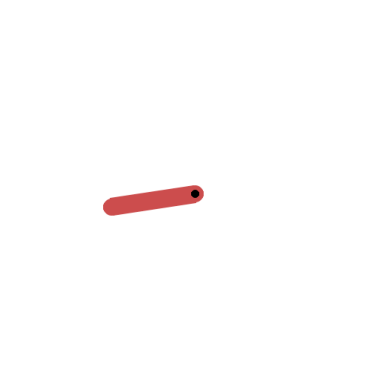

In [3]:
env = gym.make("Pendulum-v1", render_mode="rgb_array")

obs, info = env.reset(seed=42)

print("Espacio de observaciones:", env.observation_space)
print("Espacio de acciones:", env.action_space)
print("Observación inicial:", obs)

plt.imshow(env.render())
plt.axis("off")
plt.show()

env.close()

In [5]:
class DiscreteTorque(gym.ActionWrapper):
    """Convierte una acción discreta en un torque."""

    def __init__(self, env, n_actions=9):
        super().__init__(env)

        self.torques = np.linspace(
            -2.0, 2.0, n_actions, dtype=np.float32
        )
        self.action_space = gym.spaces.Discrete(n_actions)

    def action(self, action):
        index = int(np.asarray(action).item())

        return np.array(
            [self.torques[index]],
            dtype=np.float32
        )


def make_env(n_actions=9, render_mode=None):
    env = gym.make(
        "Pendulum-v1",
        render_mode=render_mode
    )

    return DiscreteTorque(env, n_actions=n_actions)

In [7]:
env = make_env()

check_env(env)

print("Acciones disponibles:", env.action_space)
print("Torques:", env.torques)

env.close()

Acciones disponibles: Discrete(9)
Torques: [-2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2. ]


In [11]:
SEED = 42
N_ACTIONS = 9

# Primera prueba para comprobar que todo funciona.
TOTAL_STEPS = 200_000

RUN = f"a{N_ACTIONS}_seed{SEED}_steps{TOTAL_STEPS}"

RESULT_DIR = Path("results") / RUN
MODEL_DIR = Path("models") / RUN

RESULT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Experimento:", RUN)

Experimento: a9_seed42_steps200000


In [13]:
train_env = Monitor(
    make_env(N_ACTIONS),
    filename=str(RESULT_DIR / "train")
)

eval_env = Monitor(make_env(N_ACTIONS))
eval_env.reset(seed=SEED + 10_000)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=str(MODEL_DIR),
    log_path=str(RESULT_DIR),
    eval_freq=5_000,
    n_eval_episodes=10,
    deterministic=True
)

model = DQN(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=1e-3,
    buffer_size=100_000,
    learning_starts=5_000,
    batch_size=64,
    gamma=0.99,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=1_000,
    exploration_fraction=0.4,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    policy_kwargs={"net_arch": [128, 128]},
    seed=SEED,
    device="cpu",
    verbose=1
)

print(model.policy.q_net)

Using cpu device
Wrapping the env in a DummyVecEnv.
QNetwork(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (q_net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=9, bias=True)
  )
)


In [15]:
try:
    model.learn(
        total_timesteps=TOTAL_STEPS,
        callback=eval_callback
    )

    model.save(str(MODEL_DIR / "final_model"))

finally:
    train_env.close()
    eval_env.close()

print("Entrenamiento terminado.")

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 200      |
|    ep_rew_mean      | -1.3e+03 |
|    exploration_rate | 0.991    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 14285    |
|    time_elapsed     | 0        |
|    total_timesteps  | 800      |
----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 200       |
|    ep_rew_mean      | -1.12e+03 |
|    exploration_rate | 0.981     |
| time/               |           |
|    episodes         | 8         |
|    fps              | 12307     |
|    time_elapsed     | 0         |
|    total_timesteps  | 1600      |
-----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 200       |
|    ep_rew_mean      | -1.19e+03 |
|    exploration_rate | 0.972     |
| time/               |           |
|  

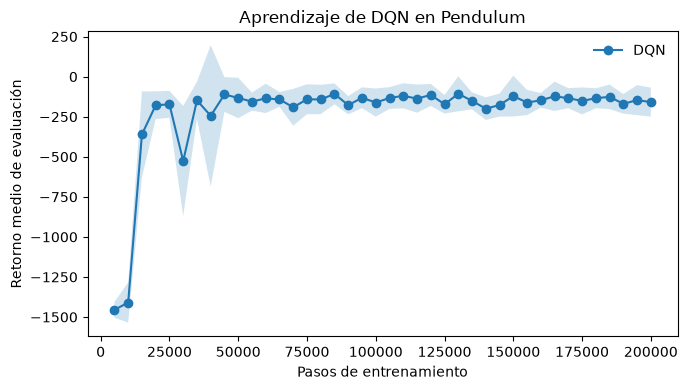

In [17]:
data = np.load(RESULT_DIR / "evaluations.npz")

steps = data["timesteps"]
returns = data["results"]

mean_return = returns.mean(axis=1)
std_return = returns.std(axis=1, ddof=1)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    steps,
    mean_return,
    marker="o",
    linewidth=1.5,
    label="DQN"
)

ax.fill_between(
    steps,
    mean_return - std_return,
    mean_return + std_return,
    alpha=0.2
)

ax.set_xlabel("Pasos de entrenamiento")
ax.set_ylabel("Retorno medio de evaluación")
ax.set_title("Aprendizaje de DQN en Pendulum")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(
    RESULT_DIR / "learning_curve.png",
    dpi=300
)

plt.show()

In [19]:
import csv

best_model = DQN.load(MODEL_DIR / "best_model.zip")


def evaluate_policy(policy_name, episode_seeds):
    env = make_env(N_ACTIONS)
    records = []

    try:
        for seed in episode_seeds:
            obs, _ = env.reset(seed=seed)
            env.action_space.seed(seed)

            total_reward = 0.0
            done = False

            while not done:
                if policy_name == "DQN":
                    action, _ = best_model.predict(
                        obs,
                        deterministic=True
                    )

                elif policy_name == "Aleatorio":
                    action = env.action_space.sample()

                else:
                    action = int(
                        np.argmin(np.abs(env.torques))
                    )

                obs, reward, terminated, truncated, _ = env.step(
                    action
                )

                total_reward += reward
                done = terminated or truncated

            records.append({
                "policy": policy_name,
                "episode_seed": seed,
                "return": total_reward
            })

    finally:
        env.close()

    return records


episode_seeds = range(20_000, 20_050)
all_records = []

for policy_name in ["Torque cero", "Aleatorio", "DQN"]:
    records = evaluate_policy(policy_name, episode_seeds)
    all_records.extend(records)

    values = np.array([record["return"] for record in records])

    print(
        f"{policy_name}: "
        f"media = {values.mean():.2f}, "
        f"desviación = {values.std(ddof=1):.2f}"
    )

with open(
    RESULT_DIR / "comparison.csv",
    "w",
    newline="",
    encoding="utf-8"
) as file:
    writer = csv.DictWriter(
        file,
        fieldnames=["policy", "episode_seed", "return"]
    )

    writer.writeheader()
    writer.writerows(all_records)

Torque cero: media = -1196.52, desviación = 353.25
Aleatorio: media = -1226.82, desviación = 283.79
DQN: media = -147.14, desviación = 90.91


In [21]:
import subprocess

completed = subprocess.run(
    [sys.executable, "-m", "pip", "freeze"],
    capture_output=True,
    text=True,
    check=True
)

Path("requirements.txt").write_text(
    completed.stdout,
    encoding="utf-8"
)

print("Dependencias guardadas en requirements.txt")

Dependencias guardadas en requirements.txt
